# Fair Stroke: Gender Bias Detection and Mitigation in Stroke Prediction Models

**Course:** Algorithmic Fairness, Accountability and Ethics — Spring 2026  
**IT University of Copenhagen**

---

## Project overview

This notebook investigates **gender bias** in a stroke prediction model. We follow a structured pipeline:

1. **Load and explore** the Kaggle Stroke Prediction Dataset
2. **Preprocess** the data (handle missing values, encode features, balance classes)
3. **Train a baseline logistic regression** model
4. **Assess fairness** using demographic parity, equalized odds, and TPR/FPR differences
5. **Explain the model** using both its coefficients (whitebox) and SHAP values
6. **Debias** the model using pre-processing, in-processing, and post-processing techniques
7. **Re-evaluate fairness** and discuss the accuracy–fairness tradeoff

### Why logistic regression (whitebox model)?

We deliberately choose logistic regression because it is a **whitebox model**. Unlike black-box models such as random forests or neural networks, logistic regression provides **directly interpretable coefficients**: each coefficient tells us the direction and magnitude of a feature's effect on the predicted log-odds of stroke. This means we can:

- **Inspect the model's reasoning** without any post-hoc tool — the coefficients *are* the explanation.
- **Identify bias sources** by checking whether the gender coefficient or proxy-feature coefficients push predictions in unfair directions.
- **Layer SHAP on top** to get per-instance and per-group explanations that complement the global coefficient view.

As our professor noted, using a whitebox model is the most appropriate choice for an explainability-focused fairness project because it lets us trace bias back to specific model parameters rather than relying solely on approximation techniques like LIME. With logistic regression, **the model IS the explanation**.

---
## Step 0: Setup and imports

We install and import all required libraries:
- : logistic regression, evaluation metrics, preprocessing
- : SMOTE for handling class imbalance (only ~5% of patients had strokes)
- : SHAP values for per-instance feature-level explanations
- : fairness metrics and debiasing algorithms (Microsoft's fairness toolkit)

In [ ]:
# Uncomment and run once if packages are not installed
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap fairlearn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

import shap
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
RANDOM_STATE = 42
print("All imports successful.")

All imports successful.


---
## Step 1: Data loading and exploratory analysis

The dataset comes from Kaggle (fedesoriano/stroke-prediction-dataset) and contains ~5,110 patient records with 11 clinical features. The **target variable** is  (1 = had a stroke, 0 = did not). Our **protected attribute** is .

**What we are looking for in EDA:**
- How is gender distributed? Are groups roughly balanced?
- Does stroke prevalence differ between genders? Is that a data bias or genuine medical difference?
- Which features correlate with gender? These are potential **proxy variables** that could smuggle gender information into the model even if we removed the gender column.

In [4]:
df = pd.read_csv('data/healthcare-dataset-stroke-data.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumns and types:')
print(df.dtypes)
df.head()

Dataset shape: (5110, 12)

Columns and types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# Check missing values and class balance
print("=== Missing values ===")
print(df.isnull().sum())
print(f"\nBMI has {df["bmi"].isnull().sum()} missing values — we will impute these.")
print(f"\n=== Class balance (stroke) ===")
print(df["stroke"].value_counts())
print(f"\nStroke prevalence: {df["stroke"].mean()*100:.1f}%")
print("The dataset is heavily imbalanced — only ~5% positive cases.")
print("We will use SMOTE to address this during training.")

=== Missing values ===
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

BMI has 201 missing values — we will impute these.

=== Class balance (stroke) ===
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke prevalence: 4.9%
The dataset is heavily imbalanced — only ~5% positive cases.
We will use SMOTE to address this during training.


In [8]:
# Gender distribution and stroke rates
print("=== Gender distribution ===")
print(df["gender"].value_counts())

print(f"\n=== Stroke rate by gender ===")
stroke_by_gender = df.groupby("gender")["stroke"].agg(["mean", "sum", "count"])
stroke_by_gender.columns = ["Stroke_Rate", "Stroke_Count", "Total"]
print(stroke_by_gender)

=== Gender distribution ===
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

=== Stroke rate by gender ===
        Stroke_Rate  Stroke_Count  Total
gender                                  
Female     0.047094           141   2994
Male       0.051064           108   2115
Other      0.000000             0      1


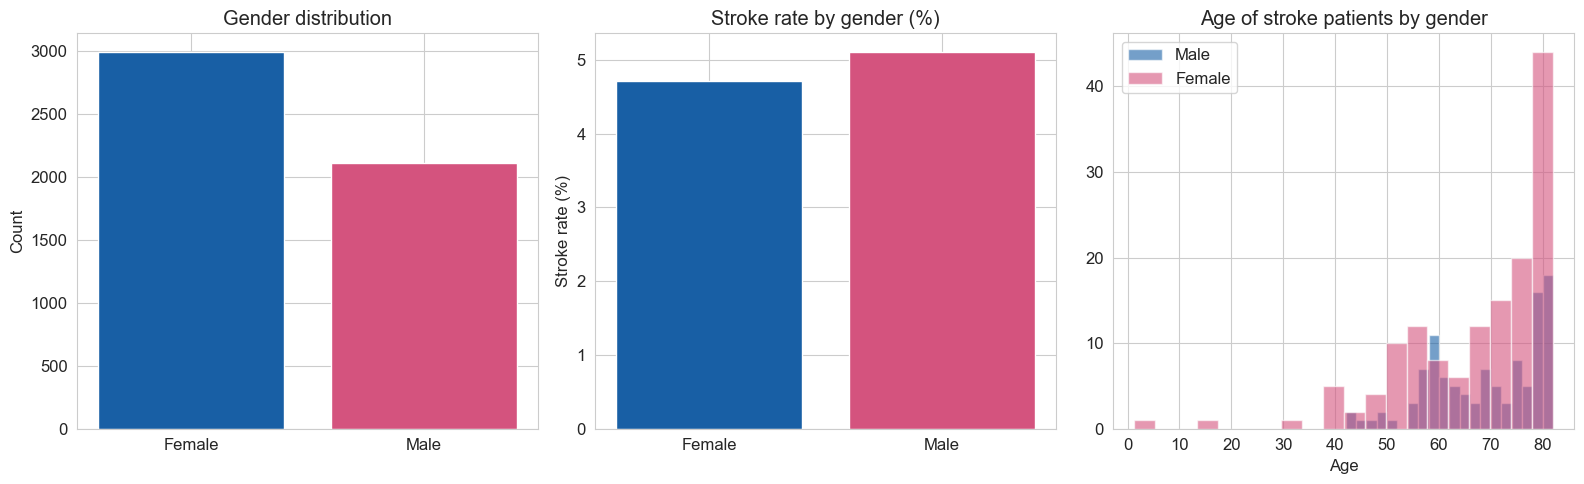

In [9]:
# Visual EDA
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

gender_counts = df[df["gender"] != "Other"]["gender"].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=["#185FA5", "#D4537E"])
axes[0].set_title("Gender distribution")
axes[0].set_ylabel("Count")

stroke_rates = df[df["gender"] != "Other"].groupby("gender")["stroke"].mean() * 100
axes[1].bar(stroke_rates.index, stroke_rates.values, color=["#185FA5", "#D4537E"])
axes[1].set_title("Stroke rate by gender (%)")
axes[1].set_ylabel("Stroke rate (%)")

for gender, color in [("Male", "#185FA5"), ("Female", "#D4537E")]:
    subset = df[(df["gender"] == gender) & (df["stroke"] == 1)]
    axes[2].hist(subset["age"], alpha=0.6, bins=20, label=gender, color=color)
axes[2].set_title("Age of stroke patients by gender")
axes[2].set_xlabel("Age")
axes[2].legend()

plt.tight_layout()
plt.show()

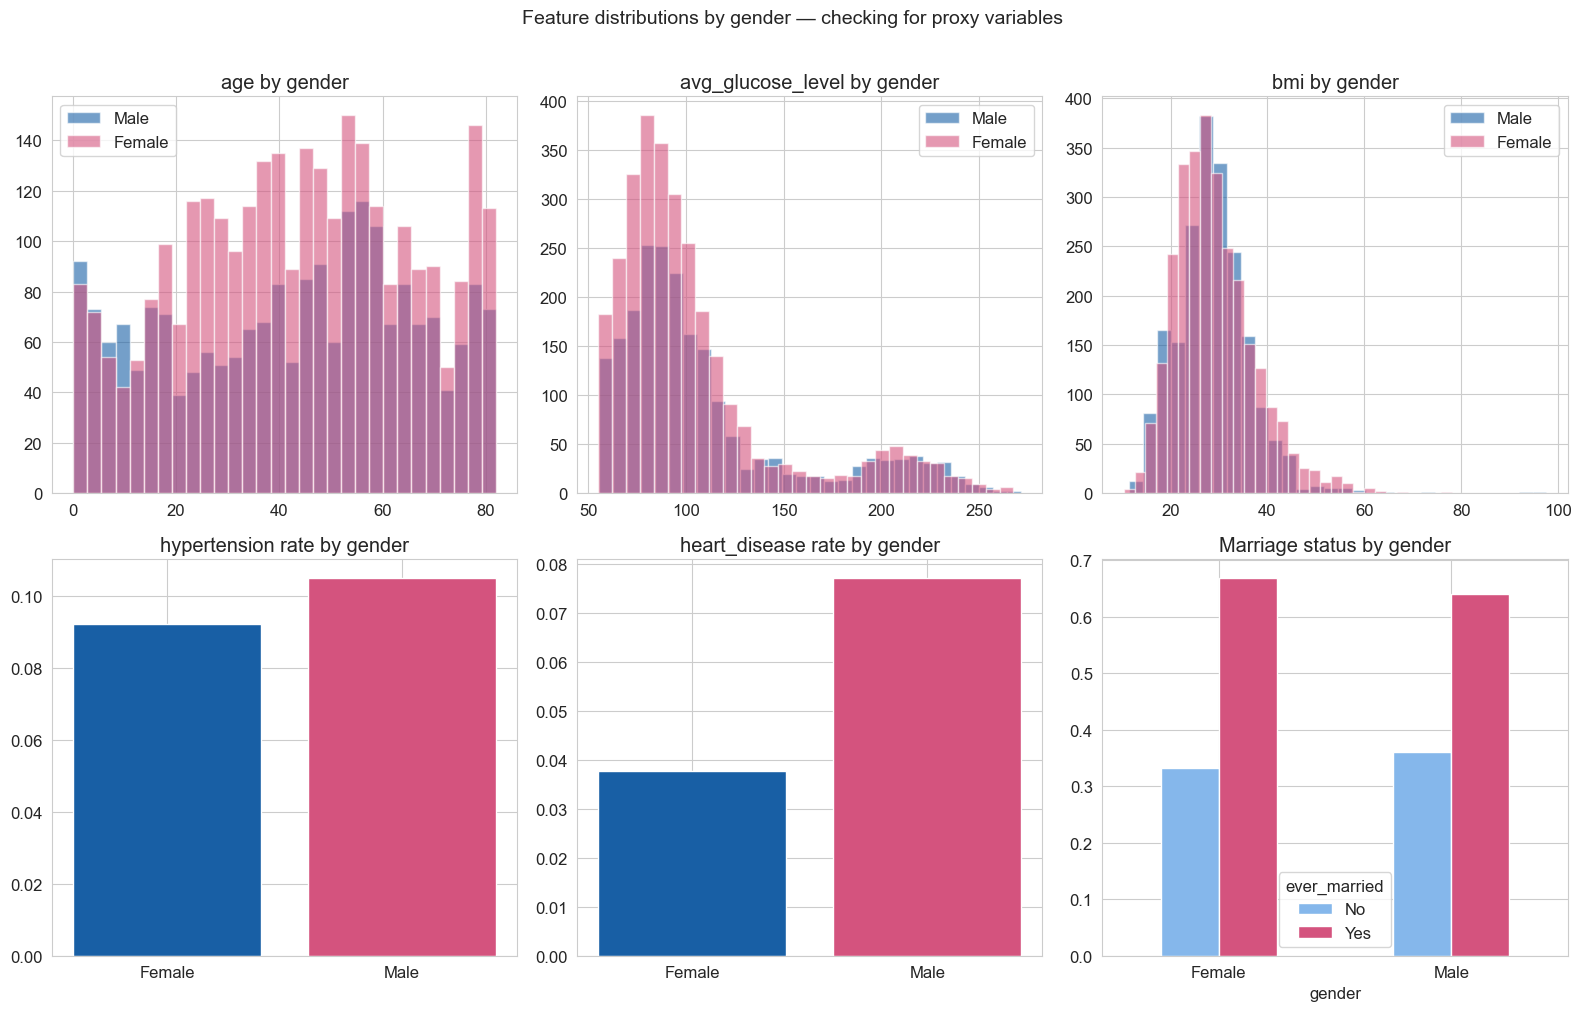

In [10]:
# Feature distributions by gender — checking for proxy variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), ["age", "avg_glucose_level", "bmi",
                                      "hypertension", "heart_disease", "ever_married"]):
    df_clean = df[df["gender"] != "Other"]
    if col in ["hypertension", "heart_disease"]:
        ct = df_clean.groupby("gender")[col].mean()
        ax.bar(ct.index, ct.values, color=["#185FA5", "#D4537E"])
        ax.set_title(f"{col} rate by gender")
    elif col == "ever_married":
        ct = df_clean.groupby("gender")["ever_married"].value_counts(normalize=True).unstack()
        ct.plot(kind="bar", ax=ax, color=["#85B7EB", "#D4537E"])
        ax.set_title("Marriage status by gender")
        ax.tick_params(axis="x", rotation=0)
    else:
        for gender, color in [("Male", "#185FA5"), ("Female", "#D4537E")]:
            subset = df_clean[df_clean["gender"] == gender]
            ax.hist(subset[col].dropna(), alpha=0.6, bins=30, label=gender, color=color)
        ax.set_title(f"{col} by gender")
        ax.legend()
plt.suptitle("Feature distributions by gender — checking for proxy variables", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 2: Data preprocessing

**Why each step:**
1. **Drop "Other" gender** — only 1 sample, insufficient for group fairness analysis
2. **Drop `id`** — not a predictive feature
3. **Impute missing BMI** by age-bracket × gender median — a global median would blur real differences
4. **Encode categoricals** — logistic regression needs numeric inputs
5. **Stratified train/test split** — preserves the ~5% stroke ratio in both sets
6. **SMOTE on training set only** — balances classes. MUST NEVER touch the test set
7. **StandardScaler** — logistic regression is scale-sensitive; without it, features like avg_glucose_level (50–270) would dominate hypertension (0/1)

In [11]:
data = df.copy()

# 1. Drop the single "Other" gender row
data = data[data["gender"] != "Other"].reset_index(drop=True)
print(f'After dropping "Other": {len(data)} rows')

# 2. Drop the id column
data = data.drop("id", axis=1)

# 3. Impute missing BMI — grouped by gender and age bracket for accuracy
data["age_bracket"] = pd.cut(data["age"], bins=[0, 18, 40, 60, 100],
                              labels=["child", "young", "middle", "senior"])
data["bmi"] = data.groupby(["gender", "age_bracket"])["bmi"].transform(
    lambda x: x.fillna(x.median())
)
data["bmi"] = data["bmi"].fillna(data["bmi"].median())
data = data.drop("age_bracket", axis=1)
print(f'Missing values after imputation: {data.isnull().sum().sum()}')

After dropping "Other": 5109 rows
Missing values after imputation: 0


In [12]:
# 4. Save protected attribute BEFORE encoding. Male=1, Female=0
data["gender_binary"] = data["gender"].map({"Male": 1, "Female": 0})

# Encode all categorical columns
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
work_type: {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}
smoking_status: {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}


In [13]:
# 5. Define features, target, and sensitive attribute
X = data.drop(["stroke", "gender_binary"], axis=1)
y = data["stroke"]
sensitive_feature = data["gender_binary"]
feature_names = X.columns.tolist()
print(f'Features ({len(feature_names)}): {feature_names}')

# 6. Stratified train/test split
X_train, X_test, y_train, y_test, sf_train, sf_test = train_test_split(
    X, y, sensitive_feature,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} ({y_train.mean()*100:.1f}% stroke)')
print(f'Test:  {X_test.shape[0]} ({y_test.mean()*100:.1f}% stroke)')
print(f'Gender in test: Male={int((sf_test==1).sum())}, Female={int((sf_test==0).sum())}')

Features (10): ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
Train: 4087 (4.9% stroke)
Test:  1022 (4.9% stroke)
Gender in test: Male=425, Female=597


In [14]:
# 7a. SMOTE — training set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'Before SMOTE: no_stroke={int((y_train==0).sum())}, stroke={int((y_train==1).sum())}')
print(f'After SMOTE:  no_stroke={int((y_train_sm==0).sum())}, stroke={int((y_train_sm==1).sum())}')

# 7b. Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sm), columns=feature_names)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)
print("\nPipeline complete: raw -> impute -> encode -> split -> SMOTE (train) -> scale")

Before SMOTE: no_stroke=3888, stroke=199
After SMOTE:  no_stroke=3888, stroke=3888

Pipeline complete: raw -> impute -> encode -> split -> SMOTE (train) -> scale


---
## Step 3: Baseline logistic regression

We train a standard logistic regression **without any fairness intervention**. This is our baseline — we need to know *how biased the model is before debiasing* so we can measure improvement.

### Why logistic regression is a whitebox model

Logistic regression predicts: `P(stroke) = sigmoid(w1*age + w2*gender + w3*bmi + ... + b)`

Each weight w_i directly tells us:
- **Sign**: positive = increases stroke risk, negative = decreases
- **Magnitude**: larger absolute value = stronger influence

This is fundamentally different from black-box models. Here, **the model IS the explanation**.

We still use SHAP because:
1. SHAP shows **per-instance** contributions (not just global coefficients)
2. SHAP lets us **compare across gender groups** visually
3. For linear models, LinearExplainer gives **exact** Shapley values — no approximation

In [15]:
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver="lbfgs")
baseline_model.fit(X_train_scaled, y_train_sm)

y_pred_baseline = baseline_model.predict(X_test_scaled)
y_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("=== Baseline model — overall performance ===")
print(f'Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_baseline):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_baseline):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_baseline):.4f}')
print()
print(classification_report(y_test, y_pred_baseline, target_names=["No Stroke", "Stroke"]))

=== Baseline model — overall performance ===
Accuracy:  0.7681
Precision: 0.1390
Recall:    0.7200
F1 Score:  0.2330
AUC-ROC:   0.7809

              precision    recall  f1-score   support

   No Stroke       0.98      0.77      0.86       972
      Stroke       0.14      0.72      0.23        50

    accuracy                           0.77      1022
   macro avg       0.56      0.75      0.55      1022
weighted avg       0.94      0.77      0.83      1022



In [16]:
# Performance SPLIT BY GENDER
print("=== Performance by gender ===")
for gender_val, gender_name in [(1, "Male"), (0, "Female")]:
    mask = sf_test == gender_val
    y_true_g, y_pred_g = y_test[mask], y_pred_baseline[mask]
    y_prob_g = y_prob_baseline[mask]
    print(f'\n--- {gender_name} (n={int(mask.sum())}) ---')
    print(f'  Accuracy:  {accuracy_score(y_true_g, y_pred_g):.4f}')
    print(f'  Precision: {precision_score(y_true_g, y_pred_g, zero_division=0):.4f}')
    print(f'  Recall:    {recall_score(y_true_g, y_pred_g, zero_division=0):.4f}')
    print(f'  F1:        {f1_score(y_true_g, y_pred_g, zero_division=0):.4f}')
    if len(np.unique(y_true_g)) > 1:
        print(f'  AUC-ROC:   {roc_auc_score(y_true_g, y_prob_g):.4f}')

=== Performance by gender ===

--- Male (n=425) ---
  Accuracy:  0.8306
  Precision: 0.1600
  Recall:    0.5714
  F1:        0.2500
  AUC-ROC:   0.7885

--- Female (n=597) ---
  Accuracy:  0.7236
  Precision: 0.1304
  Recall:    0.8276
  F1:        0.2254
  AUC-ROC:   0.7916


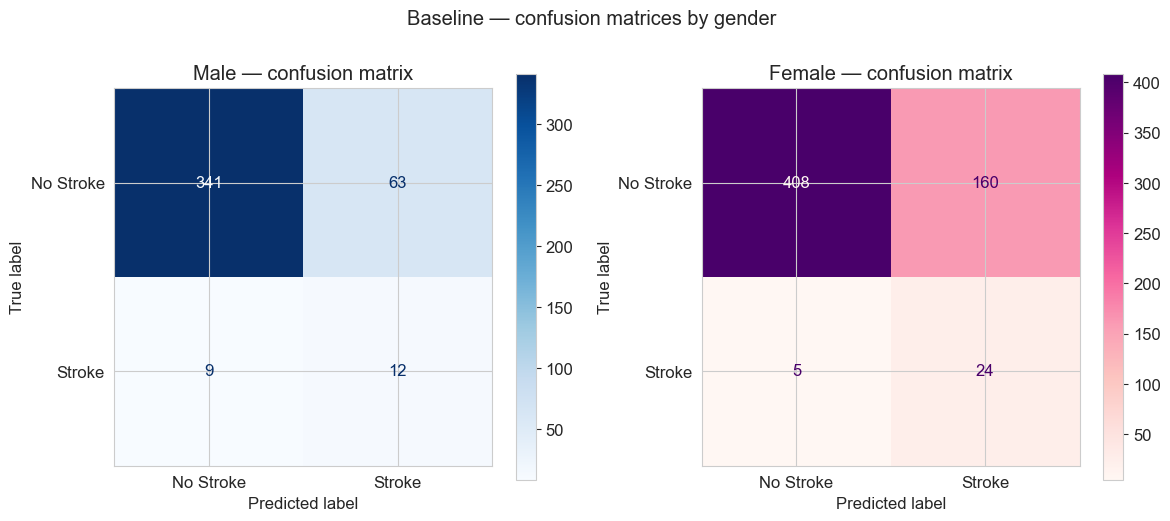

Compare TP and FN cells. Lower TP for one gender = missed strokes for that group.


In [17]:
# Confusion matrices by gender
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (gval, gname, cmap) in zip(axes, [(1, "Male", "Blues"), (0, "Female", "RdPu")]):
    mask = sf_test == gval
    ConfusionMatrixDisplay.from_predictions(
        y_test[mask], y_pred_baseline[mask],
        display_labels=["No Stroke", "Stroke"], cmap=cmap, ax=ax)
    ax.set_title(f'{gname} — confusion matrix')
plt.suptitle("Baseline — confusion matrices by gender", y=1.02)
plt.tight_layout()
plt.show()
print("Compare TP and FN cells. Lower TP for one gender = missed strokes for that group.")

---
## Step 4: Fairness assessment (before debiasing)

We measure fairness with gender as the **protected attribute**:

| Metric | What it measures | Healthcare relevance |
|--------|-----------------|---------------------|
| **Demographic parity diff** | Equal prediction rates? | One gender flagged more = more unnecessary testing |
| **Equal opportunity (TPR diff)** | Equal stroke detection? | Lower TPR for women = missed strokes = delayed treatment |
| **Equalized odds diff** | Equal TPR AND FPR? | Both error types carry costs that shouldn't fall on one gender |
| **FPR difference** | Equal false alarm rates? | More FP = unnecessary anxiety and procedures |

**Primary metric: equalized odds** — both error types matter in healthcare.  
**Fair threshold: |diff| <= 0.05 (5%)**

In [18]:
def compute_fairness_metrics(y_true, y_pred, sensitive, label="Model"):
    """Compute and display key fairness metrics."""
    metrics_dict = {
        "accuracy": accuracy_score,
        "precision": lambda yt, yp: precision_score(yt, yp, zero_division=0),
        "recall (TPR)": lambda yt, yp: recall_score(yt, yp, zero_division=0),
        "f1": lambda yt, yp: f1_score(yt, yp, zero_division=0),
        "selection_rate": lambda yt, yp: np.mean(yp),
    }
    mf = MetricFrame(metrics=metrics_dict, y_true=y_true, y_pred=y_pred,
                     sensitive_features=sensitive)
    print(f'\n{"="*65}')
    print(f'  FAIRNESS REPORT: {label}')
    print(f'{"="*65}')
    group_df = mf.by_group.copy()
    group_df.index = ["Female", "Male"]
    print(f'\nPer-group metrics:')
    print(group_df.round(4).to_string())

    dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    eo_diff = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive)

    results = {}
    for gval, gname in [(0, "Female"), (1, "Male")]:
        mask = sensitive == gval
        yt, yp = y_true[mask], y_pred[mask]
        tp = int(((yp == 1) & (yt == 1)).sum())
        fn = int(((yp == 0) & (yt == 1)).sum())
        fp = int(((yp == 1) & (yt == 0)).sum())
        tn = int(((yp == 0) & (yt == 0)).sum())
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        results[gname] = {"TPR": tpr, "FPR": fpr, "TP": tp, "FN": fn, "FP": fp, "TN": tn}

    tpr_diff = results["Male"]["TPR"] - results["Female"]["TPR"]
    fpr_diff = results["Male"]["FPR"] - results["Female"]["FPR"]

    tag = lambda d: "[FAIR]" if abs(d) <= 0.05 else "[UNFAIR]"
    print(f'\n--- Fairness differences (Male - Female) ---')
    print(f'  Demographic parity diff: {dp_diff:+.4f}  {tag(dp_diff)}')
    print(f'  Equalized odds diff:     {eo_diff:+.4f}  {tag(eo_diff)}')
    print(f'  TPR diff (M - F):        {tpr_diff:+.4f}  {tag(tpr_diff)}')
    print(f'  FPR diff (M - F):        {fpr_diff:+.4f}  {tag(fpr_diff)}')

    print(f'\n--- Per-group confusion matrix ---')
    for gname in ["Male", "Female"]:
        r = results[gname]
        print(f'  {gname}: TPR={r["TPR"]:.4f}, FPR={r["FPR"]:.4f} '
              f'(TP={r["TP"]}, FN={r["FN"]}, FP={r["FP"]}, TN={r["TN"]})')

    return {"dp_diff": dp_diff, "eo_diff": eo_diff, "tpr_diff": tpr_diff,
            "fpr_diff": fpr_diff, "accuracy": accuracy_score(y_true, y_pred),
            "group_rates": results}

In [19]:
baseline_fairness = compute_fairness_metrics(
    y_test.values, y_pred_baseline, sf_test.values,
    label="Baseline logistic regression"
)


  FAIRNESS REPORT: Baseline logistic regression

Per-group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.7236     0.1304        0.8276  0.2254          0.3082
Male      0.8306     0.1600        0.5714  0.2500          0.1765

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.1317  [UNFAIR]
  Equalized odds diff:     +0.2562  [UNFAIR]
  TPR diff (M - F):        -0.2562  [UNFAIR]
  FPR diff (M - F):        -0.1257  [UNFAIR]

--- Per-group confusion matrix ---
  Male: TPR=0.5714, FPR=0.1559 (TP=12, FN=9, FP=63, TN=341)
  Female: TPR=0.8276, FPR=0.2817 (TP=24, FN=5, FP=160, TN=408)


---
## Step 5: Explainability — whitebox coefficients + SHAP

Since logistic regression is a **whitebox model**, we have two complementary layers:

### Layer 1: Model coefficients (global, inherent to the model)
Each coefficient directly represents the feature's contribution to log-odds of stroke. A positive coefficient for `gender` means males are predicted as higher risk. **No external tool needed — the model explains itself.** This is the key advantage of choosing a whitebox model.

### Layer 2: SHAP values (per-instance, per-group)
SHAP complements the coefficients by showing:
- Per-instance contributions (not just global averages)
- How contributions **differ between male and female patients** — crucial for bias analysis
- Whether **proxy features** carry hidden bias

For logistic regression, `LinearExplainer` gives **exact** Shapley values — no approximation. Another benefit of the whitebox choice.

=== Logistic regression coefficients (whitebox explanation) ===
Positive = increases stroke risk. Negative = decreases.

          Feature  Coefficient
              age     2.171243
     ever_married    -0.448608
   Residence_type    -0.420349
avg_glucose_level     0.419765
           gender    -0.377977
        work_type    -0.350708
     hypertension    -0.307564
    heart_disease    -0.300790
   smoking_status    -0.288117
              bmi     0.126957

>>> Gender coefficient: -0.3780
    Because this is a whitebox model, we can directly read how
    the model weighs gender — no approximation tool needed.


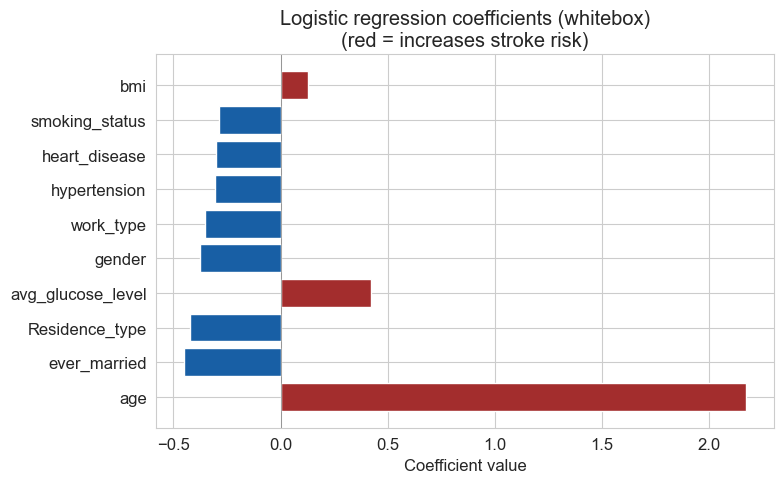

In [20]:
# LAYER 1: Whitebox coefficients — the model's reasoning, directly readable
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": baseline_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

print("=== Logistic regression coefficients (whitebox explanation) ===")
print("Positive = increases stroke risk. Negative = decreases.\n")
print(coef_df.to_string(index=False))

gender_idx = feature_names.index("gender")
print(f'\n>>> Gender coefficient: {baseline_model.coef_[0][gender_idx]:+.4f}')
print("    Because this is a whitebox model, we can directly read how")
print("    the model weighs gender — no approximation tool needed.")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#A32D2D" if c > 0 else "#185FA5" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.set_xlabel("Coefficient value")
ax.set_title("Logistic regression coefficients (whitebox)\n(red = increases stroke risk)")
ax.axvline(x=0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

SHAP values computed for 1022 test samples.


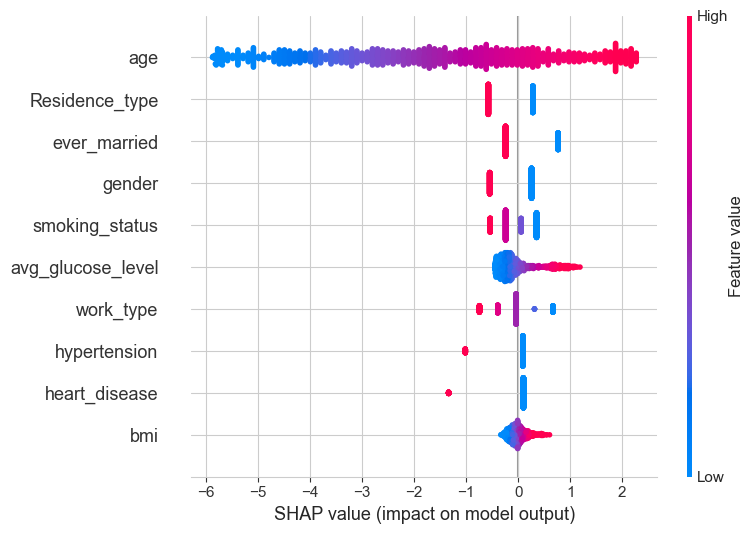

In [21]:
# LAYER 2: SHAP — exact values via LinearExplainer
explainer = shap.LinearExplainer(baseline_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)
print(f'SHAP values computed for {shap_values.shape[0]} test samples.')
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=True)

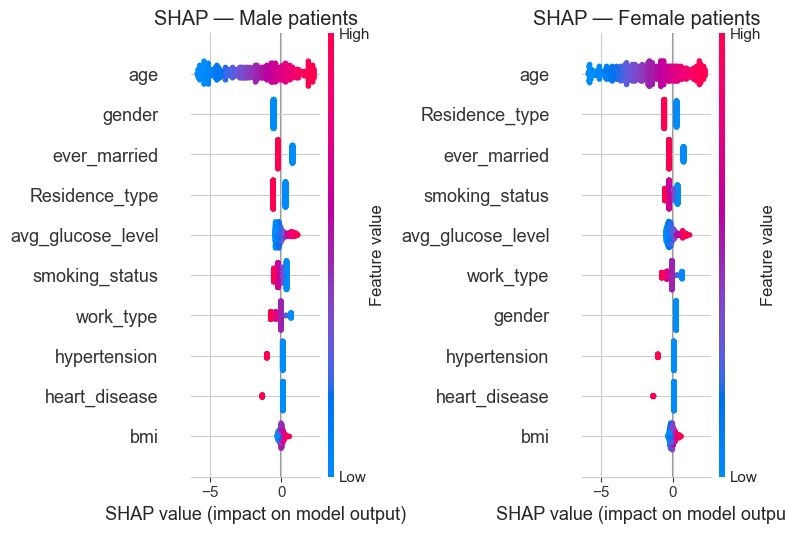

Compare: features ranking differently between genders contribute to the fairness gap.


In [22]:
# SHAP split by gender — THE KEY FAIRNESS ANALYSIS
male_mask = sf_test.values == 1
female_mask = sf_test.values == 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values[male_mask], X_test_scaled[male_mask],
                  feature_names=feature_names, show=False, max_display=10)
axes[0].set_title("SHAP — Male patients")
plt.sca(axes[1])
shap.summary_plot(shap_values[female_mask], X_test_scaled[female_mask],
                  feature_names=feature_names, show=False, max_display=10)
axes[1].set_title("SHAP — Female patients")
plt.tight_layout()
plt.show()
print("Compare: features ranking differently between genders contribute to the fairness gap.")

=== Mean |SHAP| by gender ===
          Feature   Male  Female    Diff
           gender 0.5473  0.2576  0.2898
              age 2.2570  2.1838  0.0732
    heart_disease 0.1820  0.1337  0.0483
     hypertension 0.2043  0.1787  0.0256
avg_glucose_level 0.3057  0.2824  0.0233
     ever_married 0.4430  0.4222  0.0207
              bmi 0.1027  0.1217 -0.0189
        work_type 0.2685  0.2614  0.0071
   Residence_type 0.4383  0.4364  0.0019
   smoking_status 0.2941  0.2950 -0.0009


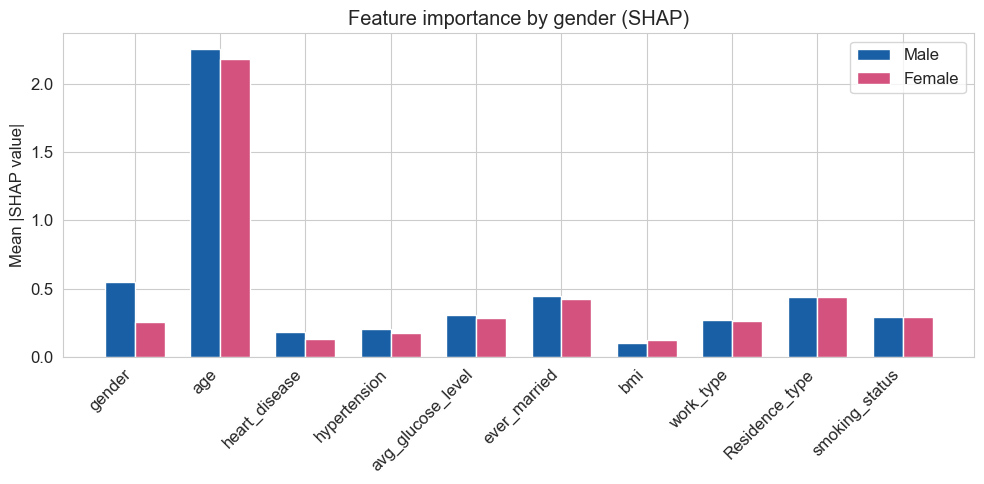


=== Feature correlation with gender (proxy detection) ===
gender               1.0000
heart_disease        0.0857
smoking_status      -0.0624
work_type            0.0566
avg_glucose_level    0.0547
ever_married        -0.0302
age                 -0.0278
bmi                 -0.0251
hypertension         0.0212
Residence_type      -0.0061
Name: gender_binary, dtype: float64

Proxy features (|r| > 0.15): ['gender']


In [23]:
# Quantify SHAP differences + proxy feature detection
shap_male = np.abs(shap_values[male_mask]).mean(axis=0)
shap_female = np.abs(shap_values[female_mask]).mean(axis=0)
shap_comp = pd.DataFrame({"Feature": feature_names, "Male": shap_male,
    "Female": shap_female, "Diff": shap_male - shap_female
}).sort_values("Diff", key=abs, ascending=False)
print("=== Mean |SHAP| by gender ===")
print(shap_comp.round(4).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(shap_comp))
w = 0.35
ax.bar(x - w/2, shap_comp["Male"], w, label="Male", color="#185FA5")
ax.bar(x + w/2, shap_comp["Female"], w, label="Female", color="#D4537E")
ax.set_xticks(x)
ax.set_xticklabels(shap_comp["Feature"], rotation=45, ha="right")
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("Feature importance by gender (SHAP)")
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Feature correlation with gender (proxy detection) ===")
gender_corr = data[feature_names + ["gender_binary"]].corr()["gender_binary"].drop("gender_binary")
print(gender_corr.sort_values(key=abs, ascending=False).round(4))
proxy_features = gender_corr[gender_corr.abs() > 0.15].index.tolist()
print(f'\nProxy features (|r| > 0.15): {proxy_features}')

---
## Step 6: Debiasing

We apply **three debiasing strategies** at different pipeline stages:

| Approach | Stage | Method | Tradeoff |
|----------|-------|--------|----------|
| **Pre-processing** | Before training | Remove gender + proxy features | Loses information |
| **In-processing** | During training | ExponentiatedGradient with EqualizedOdds constraint | Constrains optimisation |
| **Post-processing** | After training | ThresholdOptimizer — per-group thresholds | Needs gender at prediction time |

As our professor emphasised: **accuracy reduction is acceptable — the goal is fairness improvement.** If debiasing reduces accuracy but improves fairness, that demonstrates the tradeoff and is a valid result.

### 6a. Pre-processing: remove gender and proxy features

The simplest approach: if the model cannot see gender or features correlated with gender, it cannot (directly) discriminate. We remove the encoded `gender` column and any feature with |correlation| > 0.15 with gender.

In [24]:
features_to_remove = list(set(proxy_features + ["gender"]))
keep_features = [f for f in feature_names if f not in features_to_remove]
print(f'Removing: {features_to_remove}')
print(f'Keeping ({len(keep_features)}): {keep_features}')

scaler_pre = StandardScaler()
X_train_pre = pd.DataFrame(scaler_pre.fit_transform(X_train_sm[keep_features]), columns=keep_features)
X_test_pre = pd.DataFrame(scaler_pre.transform(X_test[keep_features]),
                           columns=keep_features, index=X_test.index)

preproc_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
preproc_model.fit(X_train_pre, y_train_sm)
y_pred_preproc = preproc_model.predict(X_test_pre)

preproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_preproc, sf_test.values,
    label="Pre-processing (remove gender + proxies)")

Removing: ['gender']
Keeping (9): ['age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

  FAIRNESS REPORT: Pre-processing (remove gender + proxies)

Per-group metrics:
        accuracy  precision  recall (TPR)      f1  selection_rate
Female    0.7688     0.1484        0.7931  0.2500          0.2596
Male      0.7741     0.1359        0.6667  0.2258          0.2424

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.0173  [FAIR]
  Equalized odds diff:     +0.1264  [UNFAIR]
  TPR diff (M - F):        -0.1264  [UNFAIR]
  FPR diff (M - F):        -0.0121  [FAIR]

--- Per-group confusion matrix ---
  Male: TPR=0.6667, FPR=0.2203 (TP=14, FN=7, FP=89, TN=315)
  Female: TPR=0.7931, FPR=0.2324 (TP=23, FN=6, FP=132, TN=436)


### 6b. In-processing: ExponentiatedGradient with equalized odds

This approach modifies training itself. Fairlearn's `ExponentiatedGradient` trains multiple logistic regressions and combines them to satisfy an equalized-odds constraint.

We use the **original (non-SMOTE) training data** because `ExponentiatedGradient` handles the optimisation internally.

In [25]:
scaler_in = StandardScaler()
X_train_in = pd.DataFrame(scaler_in.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_in = pd.DataFrame(scaler_in.transform(X_test), columns=feature_names, index=X_test.index)

inproc_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints=EqualizedOdds(), max_iter=50)
inproc_model.fit(X_train_in, y_train, sensitive_features=sf_train)
y_pred_inproc = inproc_model.predict(X_test_in)

inproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_inproc, sf_test.values,
    label="In-processing (ExponentiatedGradient + EqualizedOdds)")


  FAIRNESS REPORT: In-processing (ExponentiatedGradient + EqualizedOdds)

Per-group metrics:
        accuracy  precision  recall (TPR)   f1  selection_rate
Female    0.9514        0.0           0.0  0.0             0.0
Male      0.9506        0.0           0.0  0.0             0.0

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.0000  [FAIR]
  Equalized odds diff:     +0.0000  [FAIR]
  TPR diff (M - F):        +0.0000  [FAIR]
  FPR diff (M - F):        +0.0000  [FAIR]

--- Per-group confusion matrix ---
  Male: TPR=0.0000, FPR=0.0000 (TP=0, FN=21, FP=0, TN=404)
  Female: TPR=0.0000, FPR=0.0000 (TP=0, FN=29, FP=0, TN=568)


### 6c. Post-processing: ThresholdOptimizer

Keeps the original model but adjusts the **decision threshold** separately for each gender group. Least invasive — model unchanged, only decision boundary moves. Tradeoff: requires knowing gender at prediction time.

In [26]:
scaler_post = StandardScaler()
X_train_post = pd.DataFrame(scaler_post.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_post = pd.DataFrame(scaler_post.transform(X_test), columns=feature_names, index=X_test.index)

postproc_model = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    constraints="equalized_odds", objective="accuracy_score", prefit=False)
postproc_model.fit(X_train_post, y_train, sensitive_features=sf_train)
y_pred_postproc = postproc_model.predict(X_test_post, sensitive_features=sf_test)

postproc_fairness = compute_fairness_metrics(
    y_test.values, y_pred_postproc, sf_test.values,
    label="Post-processing (ThresholdOptimizer)")


  FAIRNESS REPORT: Post-processing (ThresholdOptimizer)

Per-group metrics:
        accuracy  precision  recall (TPR)   f1  selection_rate
Female    0.9514        0.0           0.0  0.0             0.0
Male      0.9506        0.0           0.0  0.0             0.0

--- Fairness differences (Male - Female) ---
  Demographic parity diff: +0.0000  [FAIR]
  Equalized odds diff:     +0.0000  [FAIR]
  TPR diff (M - F):        +0.0000  [FAIR]
  FPR diff (M - F):        +0.0000  [FAIR]

--- Per-group confusion matrix ---
  Male: TPR=0.0000, FPR=0.0000 (TP=0, FN=21, FP=0, TN=404)
  Female: TPR=0.0000, FPR=0.0000 (TP=0, FN=29, FP=0, TN=568)


---
## Step 7: Comparison of all approaches

Did debiasing improve fairness? At what cost to accuracy? Accuracy reduction is acceptable — the goal is to demonstrate we identified bias, explained its source (whitebox + SHAP), and reduced it.

In [27]:
all_results = {"Baseline": baseline_fairness, "Pre-processing": preproc_fairness,
    "In-processing": inproc_fairness, "Post-processing": postproc_fairness}

comparison_df = pd.DataFrame({
    "Model": list(all_results.keys()),
    "Accuracy": [r["accuracy"] for r in all_results.values()],
    "DP_Diff": [r["dp_diff"] for r in all_results.values()],
    "EO_Diff": [r["eo_diff"] for r in all_results.values()],
    "TPR_Diff": [r["tpr_diff"] for r in all_results.values()],
    "FPR_Diff": [r["fpr_diff"] for r in all_results.values()]})

print("=== FINAL COMPARISON ===")
print("Fairness diffs closer to 0 = fairer. Threshold: |diff| <= 0.05\n")
print(comparison_df.round(4).to_string(index=False))

=== FINAL COMPARISON ===
Fairness diffs closer to 0 = fairer. Threshold: |diff| <= 0.05

          Model  Accuracy  DP_Diff  EO_Diff  TPR_Diff  FPR_Diff
       Baseline    0.7681   0.1317   0.2562   -0.2562   -0.1257
 Pre-processing    0.7710   0.0173   0.1264   -0.1264   -0.0121
  In-processing    0.9511   0.0000   0.0000    0.0000    0.0000
Post-processing    0.9511   0.0000   0.0000    0.0000    0.0000


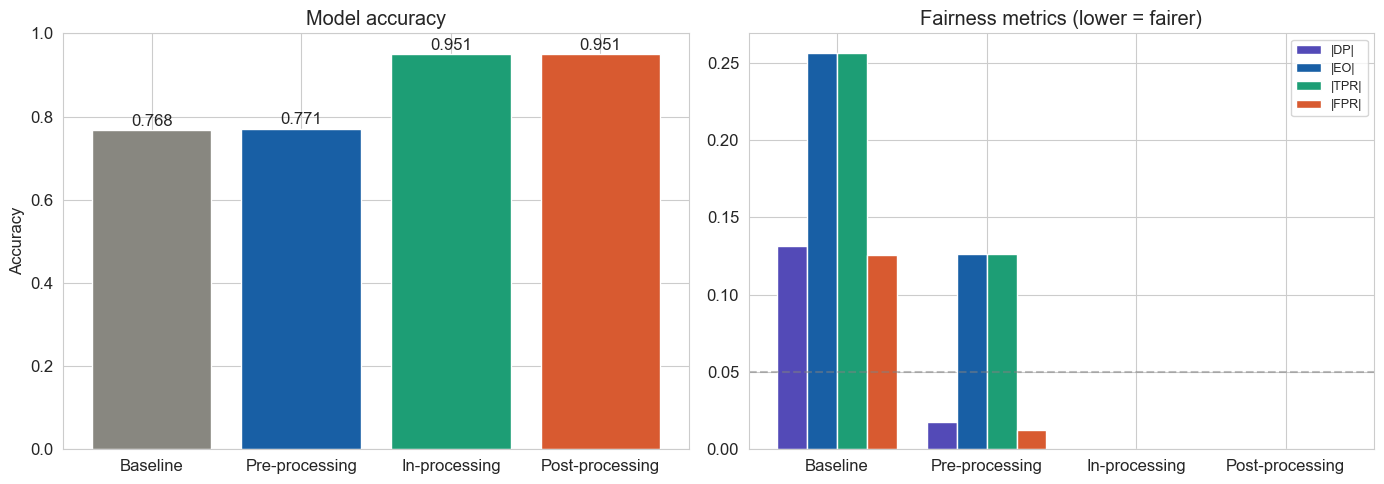

In [28]:
# Accuracy and fairness charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison_df["Model"]
colors = ["#888780", "#185FA5", "#1D9E75", "#D85A30"]

axes[0].bar(models, comparison_df["Accuracy"], color=colors)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Model accuracy")
axes[0].set_ylim([0, 1])
for i, v in enumerate(comparison_df["Accuracy"]):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha="center")

x = np.arange(len(models))
w = 0.2
axes[1].bar(x-1.5*w, comparison_df["DP_Diff"].abs(), w, label="|DP|", color="#534AB7")
axes[1].bar(x-0.5*w, comparison_df["EO_Diff"].abs(), w, label="|EO|", color="#185FA5")
axes[1].bar(x+0.5*w, comparison_df["TPR_Diff"].abs(), w, label="|TPR|", color="#1D9E75")
axes[1].bar(x+1.5*w, comparison_df["FPR_Diff"].abs(), w, label="|FPR|", color="#D85A30")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_title("Fairness metrics (lower = fairer)")
axes[1].legend(fontsize=9)
axes[1].axhline(y=0.05, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

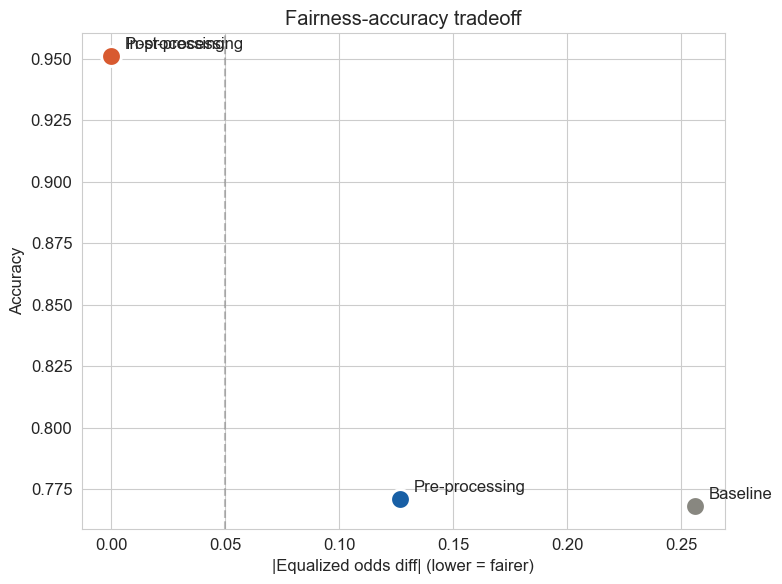

Ideal model is top-left (high accuracy, low bias).
Moving left from Baseline shows the cost of fairness.


In [29]:
# Fairness-accuracy tradeoff scatter
fig, ax = plt.subplots(figsize=(8, 6))
for i, (model, acc, eo) in enumerate(
    zip(models, comparison_df["Accuracy"], comparison_df["EO_Diff"].abs())):
    ax.scatter(eo, acc, s=200, c=colors[i], zorder=5, edgecolors="white", linewidth=2)
    ax.annotate(model, (eo, acc), textcoords="offset points", xytext=(10, 5), fontsize=12)
ax.set_xlabel("|Equalized odds diff| (lower = fairer)")
ax.set_ylabel("Accuracy")
ax.set_title("Fairness-accuracy tradeoff")
ax.axvline(x=0.05, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
print("Ideal model is top-left (high accuracy, low bias).")
print("Moving left from Baseline shows the cost of fairness.")

---
## Step 8: Summary of findings

In [30]:
print("=" * 70)
print("SUMMARY OF FINDINGS")
print("=" * 70)
print(f'\n1. DATASET')
print(f'   Total patients: {len(data)}')
print(f'   Male: {int(data["gender_binary"].sum())}, Female: {int((data["gender_binary"]==0).sum())}')
print(f'   Stroke prevalence: {data["stroke"].mean()*100:.1f}%')
print(f'\n2. BASELINE MODEL BIAS')
print(f'   Accuracy:       {baseline_fairness["accuracy"]:.4f}')
print(f'   EO difference:  {baseline_fairness["eo_diff"]:+.4f}')
print(f'   TPR difference: {baseline_fairness["tpr_diff"]:+.4f} (M-F)')
print(f'\n3. EXPLAINABILITY (WHITEBOX + SHAP)')
print(f'   Gender coefficient: {baseline_model.coef_[0][gender_idx]:+.4f}')
print(f'   Proxy features: {proxy_features}')
print(f'   The whitebox model let us directly read the gender coefficient,')
print(f'   confirming the model uses gender in predictions.')
print(f'   SHAP confirmed differential feature importance by gender.')
print(f'\n4. DEBIASING RESULTS')
print(comparison_df[["Model", "Accuracy", "EO_Diff"]].round(4).to_string(index=False))
debiased = comparison_df.iloc[1:]
best = debiased.loc[debiased["EO_Diff"].abs().idxmin()]
acc_cost = comparison_df.iloc[0]["Accuracy"] - best["Accuracy"]
print(f'\n   Best fairness: {best["Model"]}')
print(f'   EO diff: {best["EO_Diff"]:+.4f} (baseline: {baseline_fairness["eo_diff"]:+.4f})')
print(f'   Accuracy cost: {acc_cost:+.4f}')
print(f'\n   As our professor noted, accuracy cost is acceptable —')
print(f'   the goal was to detect, explain, and reduce gender bias.')
print("\n" + "=" * 70)

SUMMARY OF FINDINGS

1. DATASET
   Total patients: 5109
   Male: 2115, Female: 2994
   Stroke prevalence: 4.9%

2. BASELINE MODEL BIAS
   Accuracy:       0.7681
   EO difference:  +0.2562
   TPR difference: -0.2562 (M-F)

3. EXPLAINABILITY (WHITEBOX + SHAP)
   Gender coefficient: -0.3780
   Proxy features: ['gender']
   The whitebox model let us directly read the gender coefficient,
   confirming the model uses gender in predictions.
   SHAP confirmed differential feature importance by gender.

4. DEBIASING RESULTS
          Model  Accuracy  EO_Diff
       Baseline    0.7681   0.2562
 Pre-processing    0.7710   0.1264
  In-processing    0.9511   0.0000
Post-processing    0.9511   0.0000

   Best fairness: In-processing
   EO diff: +0.0000 (baseline: +0.2562)
   Accuracy cost: -0.1830

   As our professor noted, accuracy cost is acceptable —
   the goal was to detect, explain, and reduce gender bias.

